histograma papito

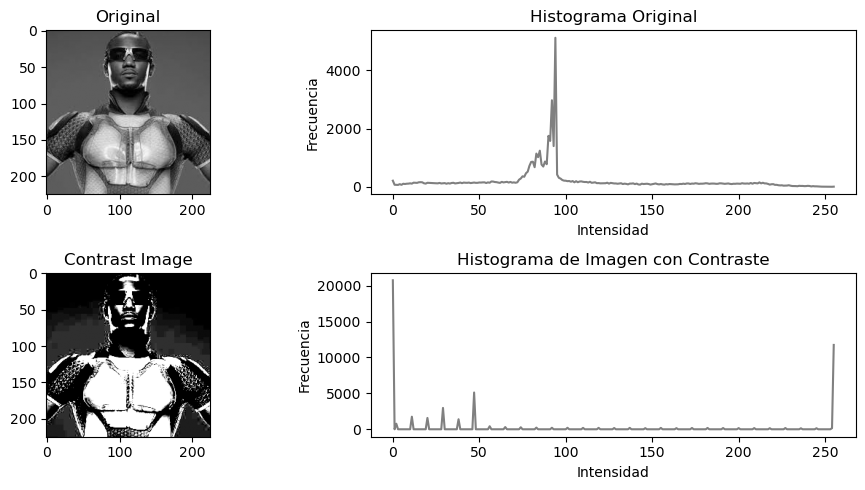

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def constraste(img, factor=1.0):
    img = img.astype(np.float32)
    media = np.mean(img)
    img_contraste = media + (img - media) * factor
    img_contraste = np.clip(img_contraste, 0, 255).astype(np.uint8)
    return img_contraste

img = cv2.imread('../negativo/audaz.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("No se encontro la imagen en ../negativo/audaz.jpg")

contrast = 9
img_fin = constraste(img, contrast)

# Calculo de histogramas
histograma_ori = cv2.calcHist([img], [0], None, [256], [0, 256])
histograma_cont = cv2.calcHist([img_fin], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')

plt.subplot(2, 2, 2)
plt.plot(histograma_ori, color='gray')
plt.title('Histograma Original')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.subplot(2, 2, 3)
plt.imshow(img_fin, cmap='gray')
plt.title('Contrast Image')

plt.subplot(2, 2, 4)
plt.plot(histograma_cont, color='gray')
plt.title('Histograma de Imagen con Contraste')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

calcular el histograma de un punto de interes de una imagen a colores 

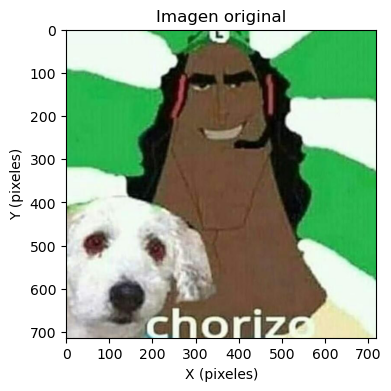

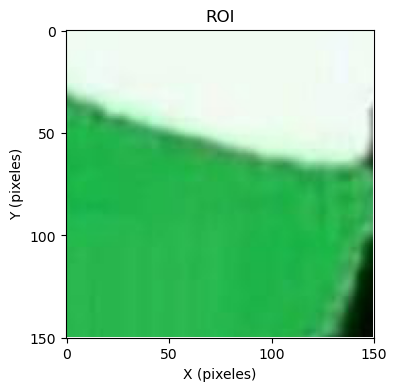

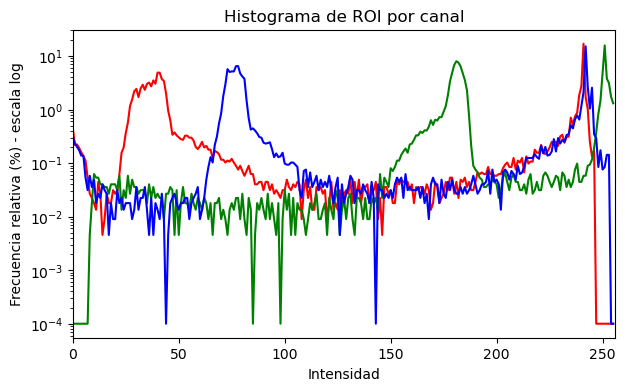

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imge = cv2.imread('chorizo.jpg')
if imge is None:
    raise FileNotFoundError("No se encontro chorizo.jpg en la carpeta actual")

img_rgb = cv2.cvtColor(imge, cv2.COLOR_BGR2RGB)
plt.rcParams['figure.figsize'] = (7, 4)

alto, ancho = img_rgb.shape[:2]
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.xticks(np.arange(0, ancho + 1, 100))
plt.yticks(np.arange(0, alto + 1, 100))
plt.xlabel('X (pixeles)')
plt.ylabel('Y (pixeles)')
plt.show()

img_cortada = img_rgb[70:220, 70:220, :]

alto_roi, ancho_roi = img_cortada.shape[:2]
plt.imshow(img_cortada)
plt.title('ROI')
plt.xticks(np.arange(0, ancho_roi + 1, 50))
plt.yticks(np.arange(0, alto_roi + 1, 50))
plt.xlabel('X (pixeles)')
plt.ylabel('Y (pixeles)')
plt.show()

color = ('r', 'g', 'b')
total_pixeles = img_cortada.shape[0] * img_cortada.shape[1]

for canal, col in enumerate(color):
    histograma = cv2.calcHist([img_cortada], [canal], None, [256], [0, 256])
    histograma_rel = (histograma / total_pixeles) * 100
    plt.plot(histograma_rel + 1e-4, color=col)

plt.xlabel('Intensidad')
plt.ylabel('Frecuencia relativa (%) - escala log')
plt.title('Histograma de ROI por canal')
plt.xlim([0, 256])
plt.yscale('log')
plt.show()

ecualizacion de un histograma "se desea normalizar una imagen a un punto optimo por histograma"

C:\Users\hp\AppData\Local\Temp\ipykernel_9132\1721409825.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(), 256, [0, 256], color='r')
C:\Users\hp\AppData\Local\Temp\ipykernel_9132\1721409825.py:36: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(ecualizar.flatten(), 256, [0, 256], color='r')


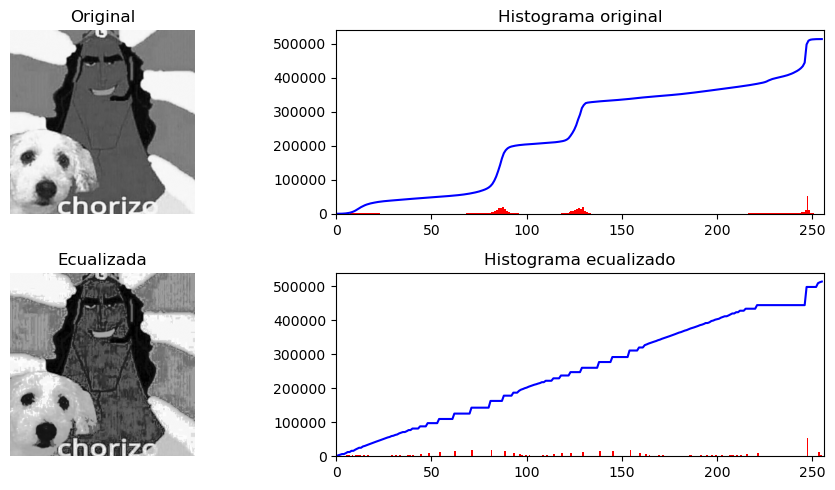

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('chorizo.jpg', 0)

# Histograma original
histograma, _ = np.histogram(img.flatten(), 256, [0, 256])
distAcum = histograma.cumsum()

# Ecualizacion
ecualizar = cv2.equalizeHist(img)
histograma_ecual, _ = np.histogram(ecualizar.flatten(), 256, [0, 256])
distAcum_ecual = histograma_ecual.cumsum()

plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(distAcum, color='b')
plt.hist(img.flatten(), 256, [0, 256], color='r')
plt.title('Histograma original')
plt.xlim([0, 256])

plt.subplot(2, 2, 3)
plt.imshow(ecualizar, cmap='gray')
plt.title('Ecualizada')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.plot(distAcum_ecual, color='b')
plt.hist(ecualizar.flatten(), 256, [0, 256], color='r')
plt.title('Histograma ecualizado')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

con colores

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('chorizo.jpg', 0)